# AlexNet Benchmark

use PY310, py311 not support torch.compile, py39 not support libnvrtc.so compatibility

In [1]:
model_name = "resnet101-torch"

import torch
from torch import nn
from torchvision import models
#import torch_mlir
import numpy as np
import iree
import iree.compiler
import iree.runtime

import warnings
warnings.filterwarnings("ignore")

from timeit import timeit as ti
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from ragdoll.compiler import *
from ragdoll.benchmark import *
import ragdoll


In [2]:
    
def get_dataframe(forward, backward, item):
    return pd.concat([
        pd.DataFrame({
            "time": forward,
            "pass": "Forward",
            "item": item
        }, index=[0]),
        pd.DataFrame({
            "time": backward,
            "pass": "Backward",
            "item": item
        }, index=[0]),
        pd.DataFrame({
            "time": forward + backward,
            "pass": "Full",
            "item": item
        }, index=[0]),
    ])

def timeit(stmt, n=100):
    return ti(stmt, globals=globals(), number=n) * 1000 / n

## Experimental

In [3]:
import torch
from torch import nn
from torchvision import models
import pandas as pd

MAGIC_NUM = 7777e-5

device = torch.device("cuda:0")
model = models.resnet101().train(False)
model.load_state_dict({k: torch.ones_like(v) * MAGIC_NUM for k, v in model.state_dict().items()})
model = model.to(device)


### PyTorch (Baseline)

In [4]:


df = pd.DataFrame()

In [5]:

model_dynamo = torch.compile(model, backend="inductor")

image = torch.randn(1, 3, 224, 224, requires_grad=True)
image = image.to(device)

output = model_dynamo(image)
grad = torch.randn_like(output)

image_np = image.detach().cpu().numpy()
grad_np = grad.cpu().numpy()

baseline_f = torch_model_benchmark(model_dynamo, 
                                 [image], 
                                 device='gpu',
                                 warmups=0,
                                 repetitions=111, 
                                 measure_count=11)
print('torch-dynamo-gpu-forward: ', baseline_f)
baseline_f = np.mean(baseline_f)
print(baseline_f)

baseline_b = torch_model_benchmark(torch.autograd.grad, 
                                 [output, [image], grad], 
                                 device='gpu',
                                 warmups=0,
                                 repetitions=111, 
                                 measure_count=11)
print('torch-dynamo-gpu-backward: ', baseline_b)
baseline_b = np.mean(baseline_b)
print(baseline_b)
df = pd.concat([df, get_dataframe(baseline_f, baseline_b, "Torch Dynamo")])
print(df)

torch-dynamo-gpu-forward:  [8.353560021868697, 8.3434535274366, 8.346074487309199, 8.361334501354545, 8.361651167810502, 8.359408056413805, 8.351826528506773, 8.356555289513356, 8.358055029299345, 8.356148477744412, 8.343564111504469]
8.353784654432882
torch-dynamo-gpu-backward:  [8.60193766116559, 8.593154592892608, 8.599631555445558, 8.618013404712483, 8.619785627669042, 8.616236776851856, 8.610093336854433, 8.610876453285282, 8.61222623335617, 8.607348007661802, 8.607274433178407]
8.60877982573393
        time      pass          item
0   8.353785   Forward  Torch Dynamo
0   8.608780  Backward  Torch Dynamo
0  16.962564      Full  Torch Dynamo


In [6]:
image = torch.randn(1, 3, 224, 224, requires_grad=True)
image = image.to(device)
output = model(image)
grad = torch.randn_like(output)

baseline_f = torch_model_benchmark(model, 
                                 [image], 
                                 device='gpu',
                                 warmups=0,
                                 repetitions=111, 
                                 measure_count=11)
print('torch-native-gpu-forward: ', baseline_f)
baseline_f = np.mean(baseline_f)
print(baseline_f)

baseline_b = torch_model_benchmark(torch.autograd.grad, 
                                 [output, [image], grad], 
                                 device='gpu',
                                 warmups=0,
                                 repetitions=111, 
                                 measure_count=11)
#baseline_b = timeit("torch.autograd.grad(output_native, [image], grad, retain_graph=True)")
print('torch-native-gpu-backward: ', baseline_b)
baseline_b = np.mean(baseline_b)
print(baseline_b)
df = pd.concat([df, get_dataframe(baseline_f, baseline_b, "Torch Native")])
print(df)

torch-native-gpu-forward:  [7.888980511877988, 7.8831595863710655, 7.889978008697161, 7.882837978032258, 7.872949446643796, 7.874733760013236, 7.871839419208668, 7.876013414011346, 7.873742765671498, 7.878075102092447, 7.874000389632341]
7.878755489295619
torch-native-gpu-backward:  [5.956080574374479, 5.766910911948831, 5.7675039546715245, 5.779991941610436, 5.777356449749555, 5.770229793212435, 5.771091895865965, 5.7925325440796644, 5.7765905837620695, 5.76966275200919, 5.776315910724906]
5.791297028364459
        time      pass          item
0   8.353785   Forward  Torch Dynamo
0   8.608780  Backward  Torch Dynamo
0  16.962564      Full  Torch Dynamo
0   7.878755   Forward  Torch Native
0   5.791297  Backward  Torch Native
0  13.670053      Full  Torch Native


In [7]:
df.style.hide(axis="index")

time,pass,item
8.353785,Forward,Torch Dynamo
8.608780,Backward,Torch Dynamo
16.962564,Full,Torch Dynamo
7.878755,Forward,Torch Native
5.791297,Backward,Torch Native
13.670053,Full,Torch Native


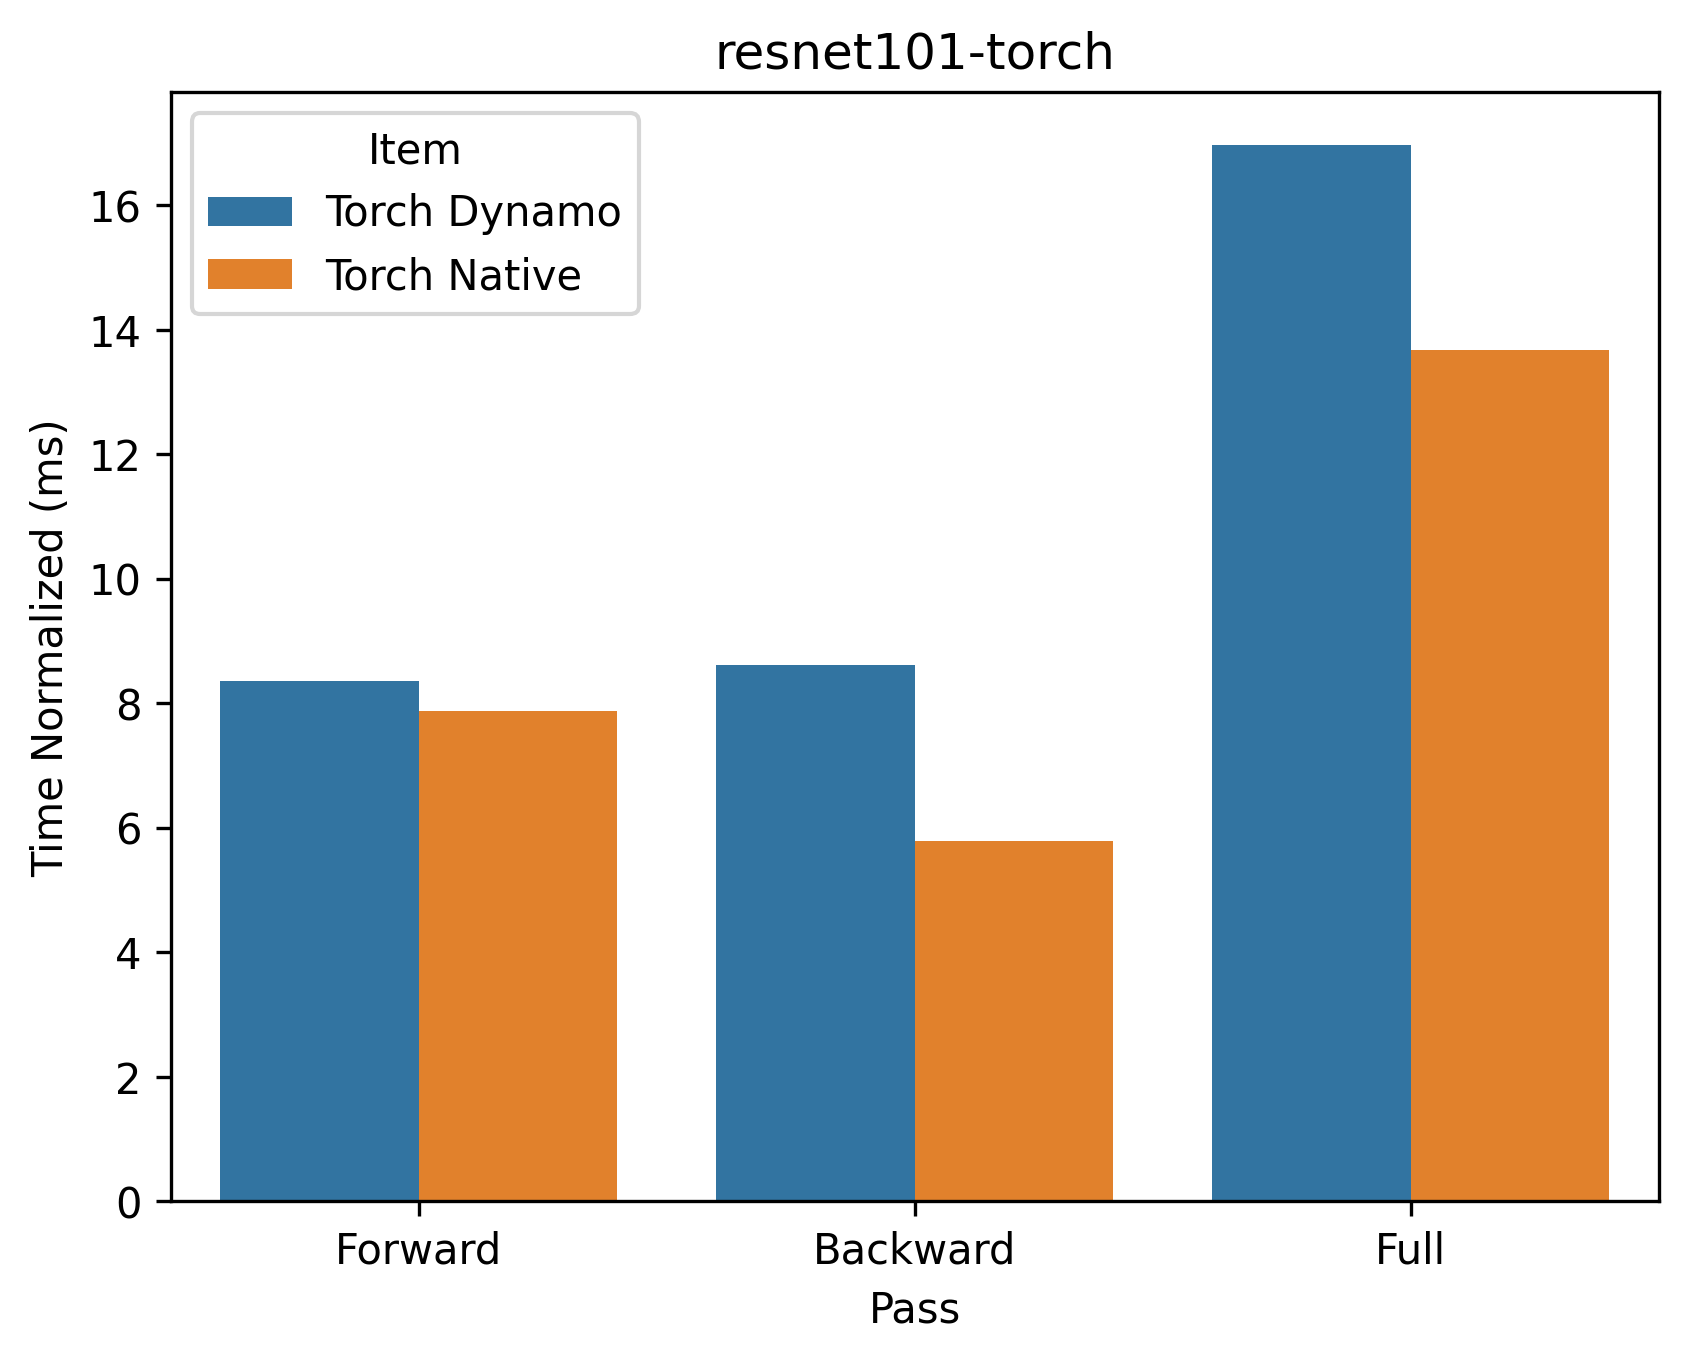

In [8]:
plt.rcParams["figure.dpi"] = 300

sns.barplot(df, x="pass", y="time", hue="item")
plt.xlabel("Pass")
plt.ylabel("Time Normalized (ms)")
plt.legend().set_title("Item")
plt.title(model_name)

plt.savefig(f"{model_name}-time.png")

In [9]:
forward = df[df["pass"] == "Forward"]
forward["acceleration"] = baseline_f / forward["time"]
forward

,time,pass,item,acceleration
0,8.353785,Forward,Torch Dynamo,0.943136
0,7.878755,Forward,Torch Native,1.000000


In [10]:
backward = df[df["pass"] == "Backward"]
backward["acceleration"] = baseline_b / backward["time"]
backward

,time,pass,item,acceleration
0,8.608780,Backward,Torch Dynamo,0.67272
0,5.791297,Backward,Torch Native,1.00000


In [11]:
full = df[df["pass"] == "Full"]
full["acceleration"] = (baseline_b + baseline_f) / full["time"]
full

,time,pass,item,acceleration
0,16.962564,Full,Torch Dynamo,0.805895
0,13.670053,Full,Torch Native,1.000000


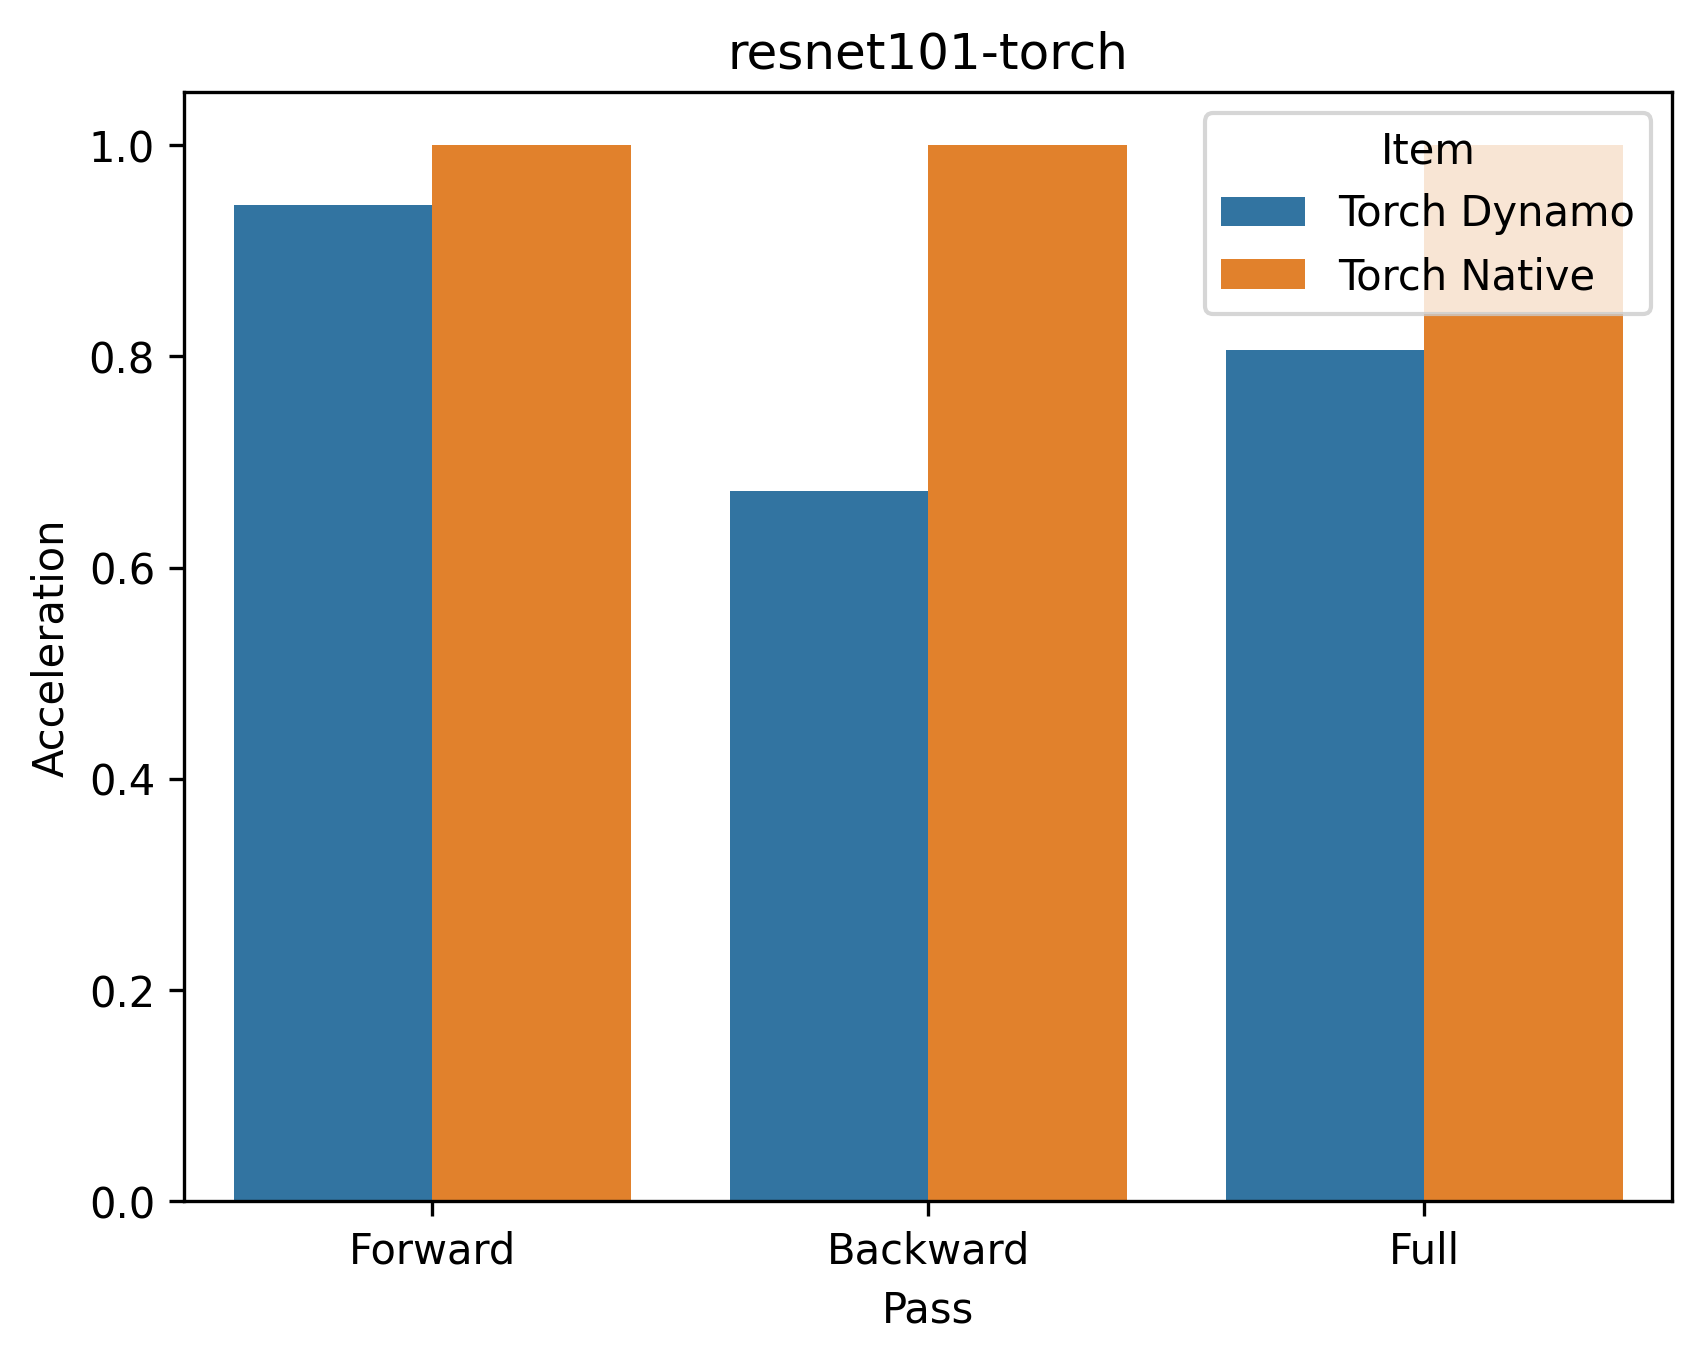

In [12]:
df = pd.concat([forward, backward, full])
df.to_csv(f"{model_name}.csv")

sns.barplot(df, x="pass", y="acceleration", hue="item")
plt.xlabel("Pass")
plt.ylabel("Acceleration")
plt.legend().set_title("Item")
plt.title(model_name)

plt.savefig(f"{model_name}-acceleration.png")